## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [6]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [7]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [8]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [9]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [10]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [11]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [12]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [13]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [14]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [15]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [16]:
inks_df = inks_df.reset_index(drop=False)

In [17]:
inds_df = inds_df.reset_index(drop=False)

In [18]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [19]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [20]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [21]:
inDKs_df.dropna(inplace=True)

In [22]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [23]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [24]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [25]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [26]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [27]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [28]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [29]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [30]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [31]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [32]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [33]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 29),
        nn.ReLU(),
        nn.Linear(29, 29),
        nn.ReLU(),
        nn.Linear(29, 29))
    def forward(self, x):
        return self.seq(x)

## Training

In [34]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=29, bias=True)
    (1): ReLU()
    (2): Linear(in_features=29, out_features=29, bias=True)
    (3): ReLU()
    (4): Linear(in_features=29, out_features=29, bias=True)
  )
)


In [35]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [36]:
EPOCHS = 10000
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.630219554901123 test 5.259935264693531
EPOCH 2:
LOSS train 4.391181723276774 test 5.074351125992603
EPOCH 3:
LOSS train 4.358523956934611 test 4.911167322509531
EPOCH 4:
LOSS train 3.967978668212891 test 4.781232079024394
EPOCH 5:
LOSS train 4.081020291646322 test 4.669359434681403
EPOCH 6:
LOSS train 3.874191999435425 test 4.574489826062698
EPOCH 7:
LOSS train 3.603886040051778 test 4.484424792060447
EPOCH 8:
LOSS train 3.484856446584066 test 4.398448602136371
EPOCH 9:
LOSS train 3.4149691104888915 test 4.3183041996714
EPOCH 10:
LOSS train 3.3070248921712238 test 4.246591213296166
EPOCH 11:
LOSS train 3.4940086682637532 test 4.179378376830192
EPOCH 12:
LOSS train 3.179979181289673 test 4.12776032087102
EPOCH 13:
LOSS train 3.1170869429906207 test 4.083945553186764
EPOCH 14:
LOSS train 3.1467103799184164 test 4.0450342076350445
EPOCH 15:
LOSS train 3.0649879614512128 test 4.007212796983142
EPOCH 16:
LOSS train 3.011515474319458 test 3.973597013370344
EPOCH 17:
LOS

LOSS train 2.348971939086914 test 3.336881604948029
EPOCH 134:
LOSS train 2.3554707368214927 test 3.335009052971567
EPOCH 135:
LOSS train 2.347824986775716 test 3.334465993348486
EPOCH 136:
LOSS train 2.4904166579246523 test 3.3327058164969734
EPOCH 137:
LOSS train 2.3563056071599324 test 3.33133334007816
EPOCH 138:
LOSS train 2.4848441163698833 test 3.331673492255233
EPOCH 139:
LOSS train 2.3611058314641316 test 3.329278419299464
EPOCH 140:
LOSS train 2.3274802049001058 test 3.326817147503173
EPOCH 141:
LOSS train 2.3502319415410358 test 3.3272723245663918
EPOCH 142:
LOSS train 2.336676557858785 test 3.324950261137932
EPOCH 143:
LOSS train 2.3331426699956257 test 3.324460352514533
EPOCH 144:
LOSS train 2.487705171108246 test 3.323291703094545
EPOCH 145:
LOSS train 2.3896839141845705 test 3.3215494429226
EPOCH 146:
LOSS train 2.3525451024373374 test 3.320945904383872
EPOCH 147:
LOSS train 2.3468451182047527 test 3.321468903928008
EPOCH 148:
LOSS train 2.3578669230143228 test 3.31905731

LOSS train 2.191441317399343 test 3.2106272472728112
EPOCH 263:
LOSS train 2.2295610149701437 test 3.209575727489424
EPOCH 264:
LOSS train 2.2339656670888264 test 3.2087373041680882
EPOCH 265:
LOSS train 2.2133220116297405 test 3.207872567694503
EPOCH 266:
LOSS train 2.209510819117228 test 3.2071170706926666
EPOCH 267:
LOSS train 2.219579331080119 test 3.2045254846012865
EPOCH 268:
LOSS train 2.3468589067459105 test 3.2038466920979767
EPOCH 269:
LOSS train 2.2065050919850666 test 3.2032632981706604
EPOCH 270:
LOSS train 2.3713613152503967 test 3.2021827995160104
EPOCH 271:
LOSS train 2.2010562221209207 test 3.2006489245325143
EPOCH 272:
LOSS train 2.2227917671203614 test 3.198707243161542
EPOCH 273:
LOSS train 2.205850092569987 test 3.1981677635270125
EPOCH 274:
LOSS train 2.1880212982495624 test 3.1960911175571614
EPOCH 275:
LOSS train 2.1936498085657754 test 3.1958228928918175
EPOCH 276:
LOSS train 2.2151421229044597 test 3.1945566014997953
EPOCH 277:
LOSS train 2.1901824434598285 te

LOSS train 2.008808970451355 test 2.953854867876131
EPOCH 392:
LOSS train 1.9985929648081462 test 2.9503365430371606
EPOCH 393:
LOSS train 2.0072055021921793 test 2.9474208674414806
EPOCH 394:
LOSS train 2.008614174524943 test 2.9451645421361703
EPOCH 395:
LOSS train 2.0315390904744466 test 2.9422426159892763
EPOCH 396:
LOSS train 2.1989542603492738 test 2.938538734810755
EPOCH 397:
LOSS train 2.0433329939842224 test 2.934190572318515
EPOCH 398:
LOSS train 1.9918931523958843 test 2.934685884440784
EPOCH 399:
LOSS train 1.9987712502479553 test 2.931613008728864
EPOCH 400:
LOSS train 1.977214558919271 test 2.9283355255582317
EPOCH 401:
LOSS train 1.9802409331003825 test 2.9287632749209616
EPOCH 402:
LOSS train 1.9682764132817587 test 2.925745106246284
EPOCH 403:
LOSS train 2.092859160900116 test 2.925918975710005
EPOCH 404:
LOSS train 1.972382911046346 test 2.923552076361194
EPOCH 405:
LOSS train 1.9885975440343222 test 2.9233024140384134
EPOCH 406:
LOSS train 1.9840325037638347 test 2.9

LOSS train 1.915111788113912 test 2.784600684739356
EPOCH 521:
LOSS train 1.8530467391014098 test 2.7831310525027493
EPOCH 522:
LOSS train 1.8652159134546915 test 2.7817400282183296
EPOCH 523:
LOSS train 1.864439876874288 test 2.7809647612474224
EPOCH 524:
LOSS train 1.8671673734982808 test 2.7796357223845045
EPOCH 525:
LOSS train 1.852986208597819 test 2.778595390218632
EPOCH 526:
LOSS train 1.8774585525194805 test 2.776837847463586
EPOCH 527:
LOSS train 1.9976787487665812 test 2.7769953421322824
EPOCH 528:
LOSS train 1.844059371948242 test 2.774730064252519
EPOCH 529:
LOSS train 1.8489929715792337 test 2.773127072731777
EPOCH 530:
LOSS train 1.8852476199467978 test 2.7734869966364424
EPOCH 531:
LOSS train 1.8365210930506388 test 2.7717345548296195
EPOCH 532:
LOSS train 1.8655414263407388 test 2.771195461622615
EPOCH 533:
LOSS train 1.8548171083132425 test 2.7689274686386742
EPOCH 534:
LOSS train 1.8467278798421225 test 2.7692706010325603
EPOCH 535:
LOSS train 1.9846357941627502 test 

...

LOSS train 1.2486095627148945 test 2.0849007285946275
EPOCH 9479:
LOSS train 1.229862912495931 test 2.084297982347246
EPOCH 9480:
LOSS train 1.2272114733854929 test 2.089060985076378
EPOCH 9481:
LOSS train 1.3239453693230947 test 2.0860226726309854
EPOCH 9482:
LOSS train 1.2325814286867778 test 2.0844507210774204
EPOCH 9483:
LOSS train 1.240391973654429 test 2.0829079138967312
EPOCH 9484:
LOSS train 1.2400507787863413 test 2.086373073205074
EPOCH 9485:
LOSS train 1.400822671254476 test 2.0870464354923177
EPOCH 9486:
LOSS train 1.2726175586382549 test 2.08926314761087
EPOCH 9487:
LOSS train 1.2377600868542988 test 2.088027182372584
EPOCH 9488:
LOSS train 1.2434854447841643 test 2.0867275623508243
EPOCH 9489:
LOSS train 1.2357737342516582 test 2.085047277743402
EPOCH 9490:
LOSS train 1.2314258257548014 test 2.085031004287071
EPOCH 9491:
LOSS train 1.2374939322471619 test 2.0888832279984255
EPOCH 9492:
LOSS train 1.3590380708376566 test 2.0876909039883755
EPOCH 9493:
LOSS train 1.23550559

LOSS train 1.2280504028002421 test 2.082359424242692
EPOCH 9605:
LOSS train 1.2283254206180572 test 2.0828048955826532
EPOCH 9606:
LOSS train 1.498588858048121 test 2.0851649856561214
EPOCH 9607:
LOSS train 1.2406523823738098 test 2.079655248085596
EPOCH 9608:
LOSS train 1.240570420026779 test 2.0870754527965443
EPOCH 9609:
LOSS train 1.230311769247055 test 2.0849265585466448
EPOCH 9610:
LOSS train 1.2397723237673441 test 2.083989156861298
EPOCH 9611:
LOSS train 1.2753277937571208 test 2.0816341956872995
EPOCH 9612:
LOSS train 1.2437131782372792 test 2.0864847233638506
EPOCH 9613:
LOSS train 1.3617238144079844 test 2.0845296791914705
EPOCH 9614:
LOSS train 1.2277398586273194 test 2.0834739883092865
EPOCH 9615:
LOSS train 1.3166440665721892 test 2.083269111287643
EPOCH 9616:
LOSS train 1.234530391295751 test 2.0802289894386723
EPOCH 9617:
LOSS train 1.244754385948181 test 2.0811613962501596
EPOCH 9618:
LOSS train 1.3661682625611624 test 2.084580328053261
EPOCH 9619:
LOSS train 1.2276822

LOSS train 1.2257561385631561 test 2.0832883576876013
EPOCH 9731:
LOSS train 1.244266583522161 test 2.0808852836335423
EPOCH 9732:
LOSS train 1.23440469900767 test 2.082540297175046
EPOCH 9733:
LOSS train 1.2368467211723329 test 2.079621902456812
EPOCH 9734:
LOSS train 1.2330845177173615 test 2.081072990614805
EPOCH 9735:
LOSS train 1.2401263197263082 test 2.0821838790307874
EPOCH 9736:
LOSS train 1.2317795674006145 test 2.0818298890276603
EPOCH 9737:
LOSS train 1.2293046712875366 test 2.079238418474269
EPOCH 9738:
LOSS train 1.232697723309199 test 2.0825488497628437
EPOCH 9739:
LOSS train 1.2400661051273345 test 2.082840172554642
EPOCH 9740:
LOSS train 1.223444112141927 test 2.080301181052659
EPOCH 9741:
LOSS train 1.236708821853002 test 2.081075159358497
EPOCH 9742:
LOSS train 1.2241320888201395 test 2.0776069918898075
EPOCH 9743:
LOSS train 1.2274131496747336 test 2.079918403463828
EPOCH 9744:
LOSS train 1.3332747101783753 test 2.0812317230594086
EPOCH 9745:
LOSS train 1.47983568310

LOSS train 1.337291924158732 test 2.0786852179554063
EPOCH 9857:
LOSS train 1.235272967815399 test 2.0796302877921864
EPOCH 9858:
LOSS train 1.2244249324003855 test 2.0785896005591002
EPOCH 9859:
LOSS train 1.244883394241333 test 2.0809231468748233
EPOCH 9860:
LOSS train 1.2306114355723063 test 2.0793095211619916
EPOCH 9861:
LOSS train 1.2235548615455627 test 2.078664394670145
EPOCH 9862:
LOSS train 1.350153108437856 test 2.0822341082228144
EPOCH 9863:
LOSS train 1.3659658094247182 test 2.080275229893733
EPOCH 9864:
LOSS train 1.3364046116669972 test 2.0769978037285264
EPOCH 9865:
LOSS train 1.230003281434377 test 2.076644423122732
EPOCH 9866:
LOSS train 1.3125857174396516 test 2.078794362582652
EPOCH 9867:
LOSS train 1.2299944659074147 test 2.074355875143847
EPOCH 9868:
LOSS train 1.2235045274098715 test 2.075420849634562
EPOCH 9869:
LOSS train 1.2255155920982361 test 2.0791223259723703
EPOCH 9870:
LOSS train 1.2244630376497905 test 2.0789654014504846
EPOCH 9871:
LOSS train 1.22154615

LOSS train 1.2673096060752869 test 2.074834574283897
EPOCH 9983:
LOSS train 1.2245097557703655 test 2.074880489952261
EPOCH 9984:
LOSS train 1.2260541558265685 test 2.075373714199718
EPOCH 9985:
LOSS train 1.2249240140120188 test 2.078540730959202
EPOCH 9986:
LOSS train 1.2323951601982117 test 2.080322235560442
EPOCH 9987:
LOSS train 1.2244518478711446 test 2.0756268276376013
EPOCH 9988:
LOSS train 1.2242842276891073 test 2.0780708848674228
EPOCH 9989:
LOSS train 1.236255019903183 test 2.0752768774997
EPOCH 9990:
LOSS train 1.2339372297128042 test 2.0753521102386108
EPOCH 9991:
LOSS train 1.2207664171854655 test 2.078502650702407
EPOCH 9992:
LOSS train 1.2198646287123363 test 2.0755312728616513
EPOCH 9993:
LOSS train 1.2322919408480326 test 2.0769098304659437
EPOCH 9994:
LOSS train 1.2238679945468902 test 2.0781210348025487
EPOCH 9995:
LOSS train 1.2271479527155558 test 2.077067276374215
EPOCH 9996:
LOSS train 1.2260128180185954 test 2.0761050894455386
EPOCH 9997:
LOSS train 1.21955940

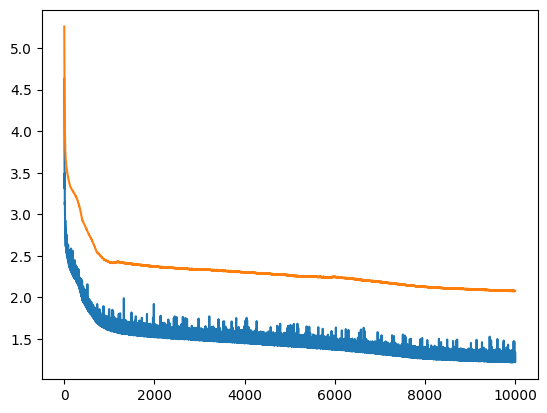

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

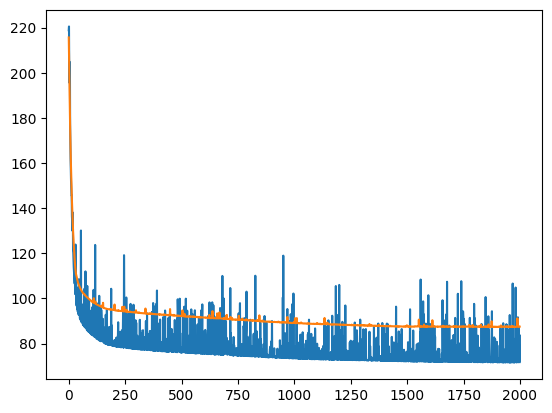

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #all
plt.plot(val_losses) #lr=0.0001

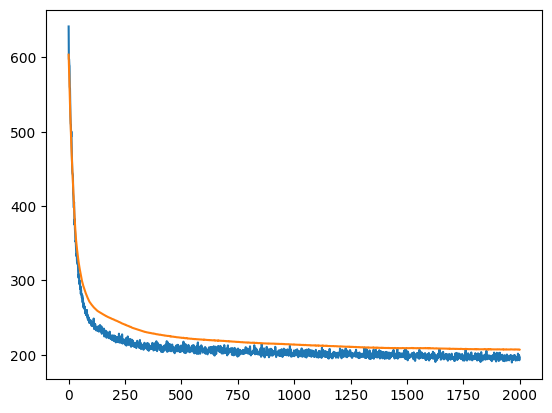

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #simulated
plt.plot(val_losses) #lr=0.0001

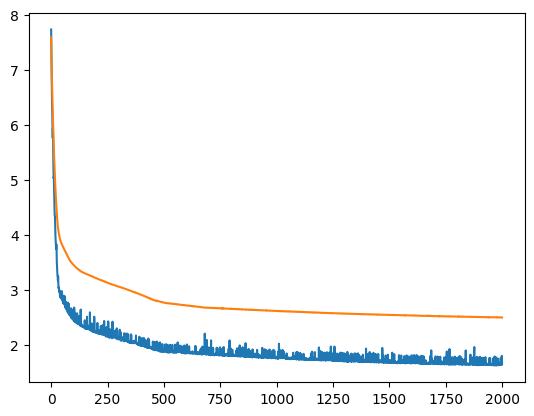

In [37]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

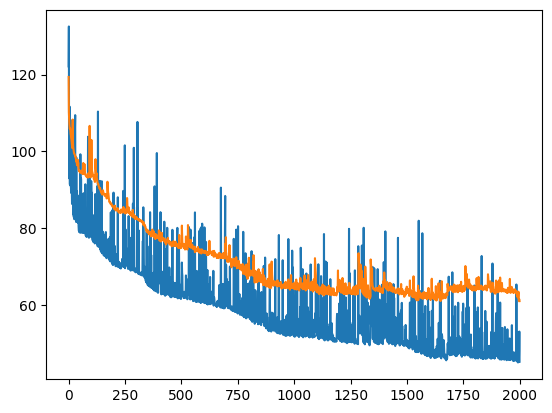

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #all
plt.plot(val_losses) #lr=0.001

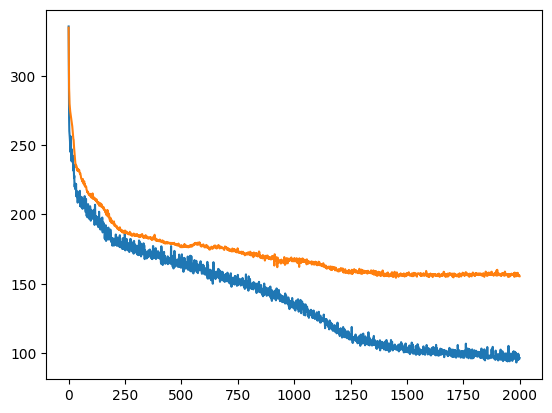

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #simulated
plt.plot(val_losses) #lr=0.001

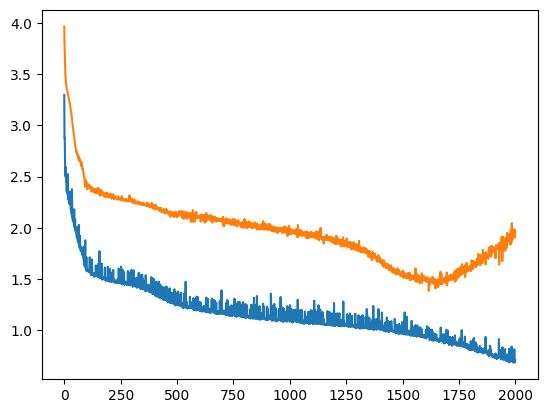

In [37]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

## Interpretability